# Nursery experiment layout TBR analysis

In [45]:
import math
import openmc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap
from openmc_model_vault import nursery_model
import json

### Geometry

In [46]:
from openmc_model_vault import baby_heights

model = nursery_model(1, baby_heights[0]) # Create nursery geometry for visualisation with the source at position 1.
geometry = model.geometry

Building BABY 1 geometry...
Building BABY 2 geometry...
Building BABY 3 geometry...
isotopes ['Ag107', 'Ag109', 'Al27', 'Ar36', 'Ar38', 'Ar40', 'As75', 'B10', 'B11', 'Be9', 'Bi209', 'C12', 'C13', 'Ca40', 'Ca42', 'Ca43', 'Ca44', 'Ca46', 'Ca48', 'Cd106', 'Cd108', 'Cd110', 'Cd111', 'Cd112', 'Cd113', 'Cd114', 'Cd116', 'Cl35', 'Cl37', 'Co59', 'Cr50', 'Cr52', 'Cr53', 'Cr54', 'Cu63', 'Cu65', 'F19', 'Fe54', 'Fe56', 'Fe57', 'Fe58', 'H1', 'H2', 'He3', 'He4', 'K39', 'K40', 'K41', 'Li6', 'Li7', 'Mg24', 'Mg25', 'Mg26', 'Mn55', 'Mo100', 'Mo92', 'Mo94', 'Mo95', 'Mo96', 'Mo97', 'Mo98', 'N14', 'N15', 'Na23', 'Nb93', 'Ni58', 'Ni60', 'Ni61', 'Ni62', 'Ni64', 'O16', 'O17', 'O18', 'P31', 'Pb204', 'Pb206', 'Pb207', 'Pb208', 'S32', 'S33', 'S34', 'S36', 'Sb121', 'Sb123', 'Si28', 'Si29', 'Si30', 'Sn112', 'Sn114', 'Sn115', 'Sn116', 'Sn117', 'Sn118', 'Sn119', 'Sn120', 'Sn122', 'Sn124', 'Ti46', 'Ti47', 'Ti48', 'Ti49', 'Ti50', 'Tl203', 'Tl205', 'W182', 'W183', 'W184', 'W186', 'Zn64', 'Zn66', 'Zn67', 'Zn68', 'Zn70',

### Vault Geometry

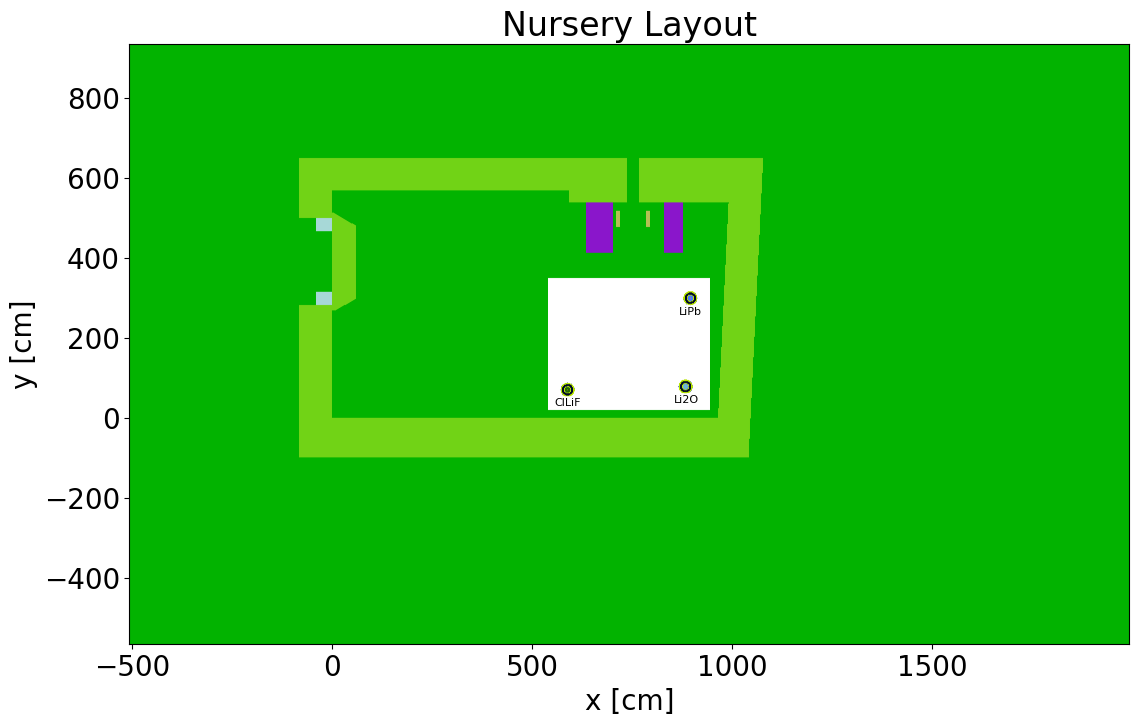

In [47]:
# Visualization
from openmc_model_vault import air, baby_positions, breeders, baby_heights
from libra_toolbox.neutronics.vault import Air

# Calculate midpoint position (center of bounding box)
min_xy = np.min(baby_positions, axis=0)
max_xy = np.max(baby_positions, axis=0)
midpoint = (min_xy + max_xy) / 2
x_c, y_c = midpoint

ax = geometry.plot(
    width=(2500, 1500),
    origin=(x_c, y_c, baby_heights[0] + 10),
    pixels=(1000, 1000),
    basis="xy",
    color_by="material",
    colors={Air: "white", air: "white"},
)

# Add breeder material labels under each BABY
for (bx, by), breeder in zip(baby_positions, breeders):
    ax.text(
        bx, by - 20,  # Adjust -20 as needed for spacing
        breeder,
        color='black',
        fontsize=8,
        ha='center',
        va='top',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
    )

ax.tick_params(axis="both", labelsize=20)
ax.set_xlabel(ax.get_xlabel(), fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
ax.set_title("Nursery Layout", fontsize=24)
plt.show()

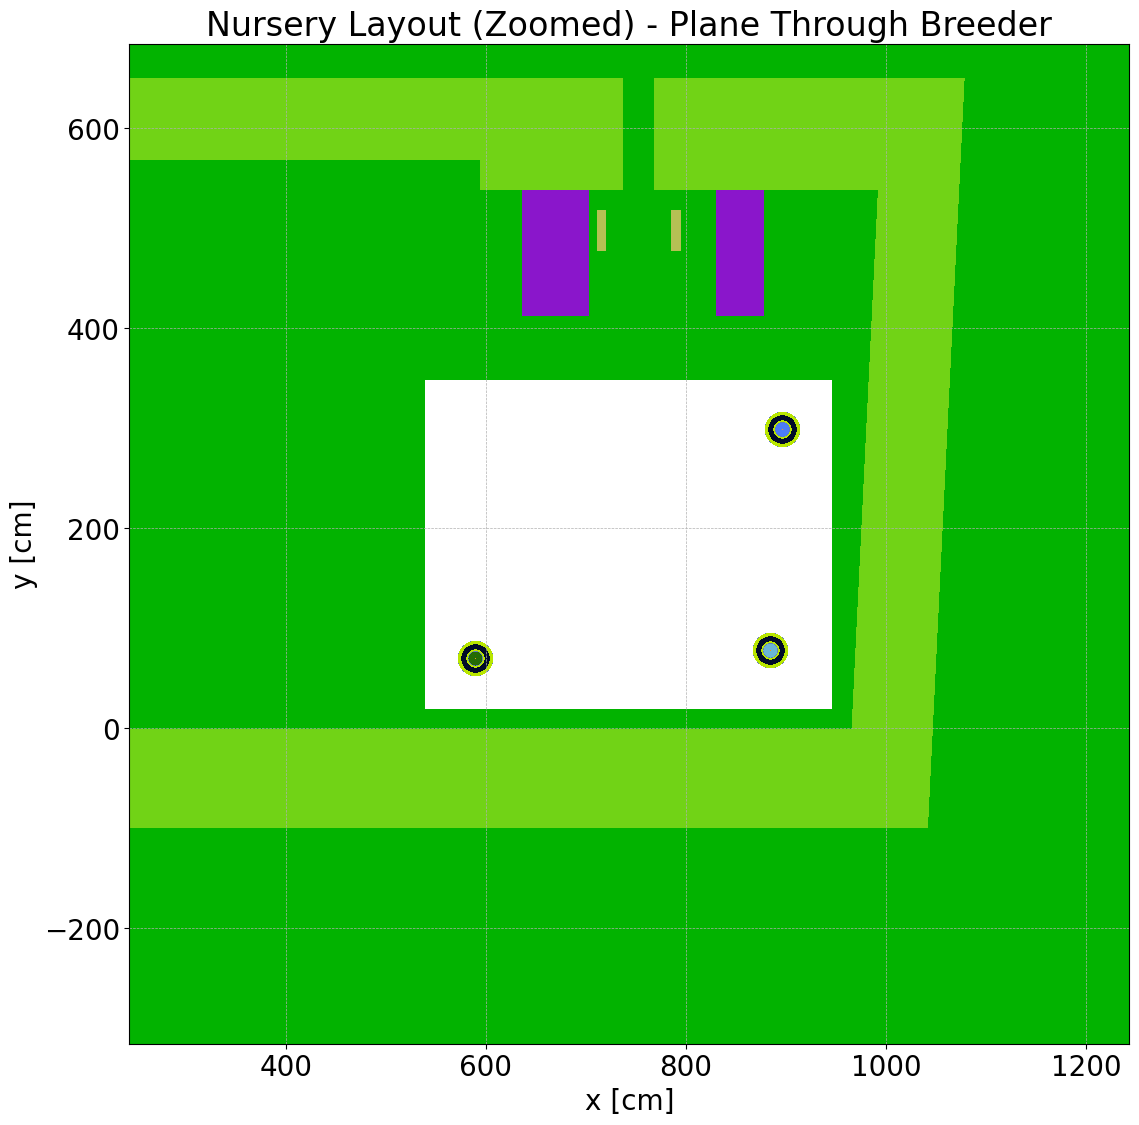

In [48]:
ax = geometry.plot(
    width=(1000, 1000),
    origin=(x_c, y_c, baby_heights[0] + 10), # z_c + 10 to cut through the breeder plane
    pixels=(1000, 1000),
    basis="xy",
    color_by="material",
    colors={Air: "white", air: "white"},
)
ax.tick_params(axis="both", labelsize=20)
ax.set_xlabel(ax.get_xlabel(), fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
ax.set_title("Nursery Layout (Zoomed) - Plane Through Breeder", fontsize=24)
plt.grid(visible=True, which='both', linestyle='--', linewidth=0.5)  # Add gridlines
plt.show()

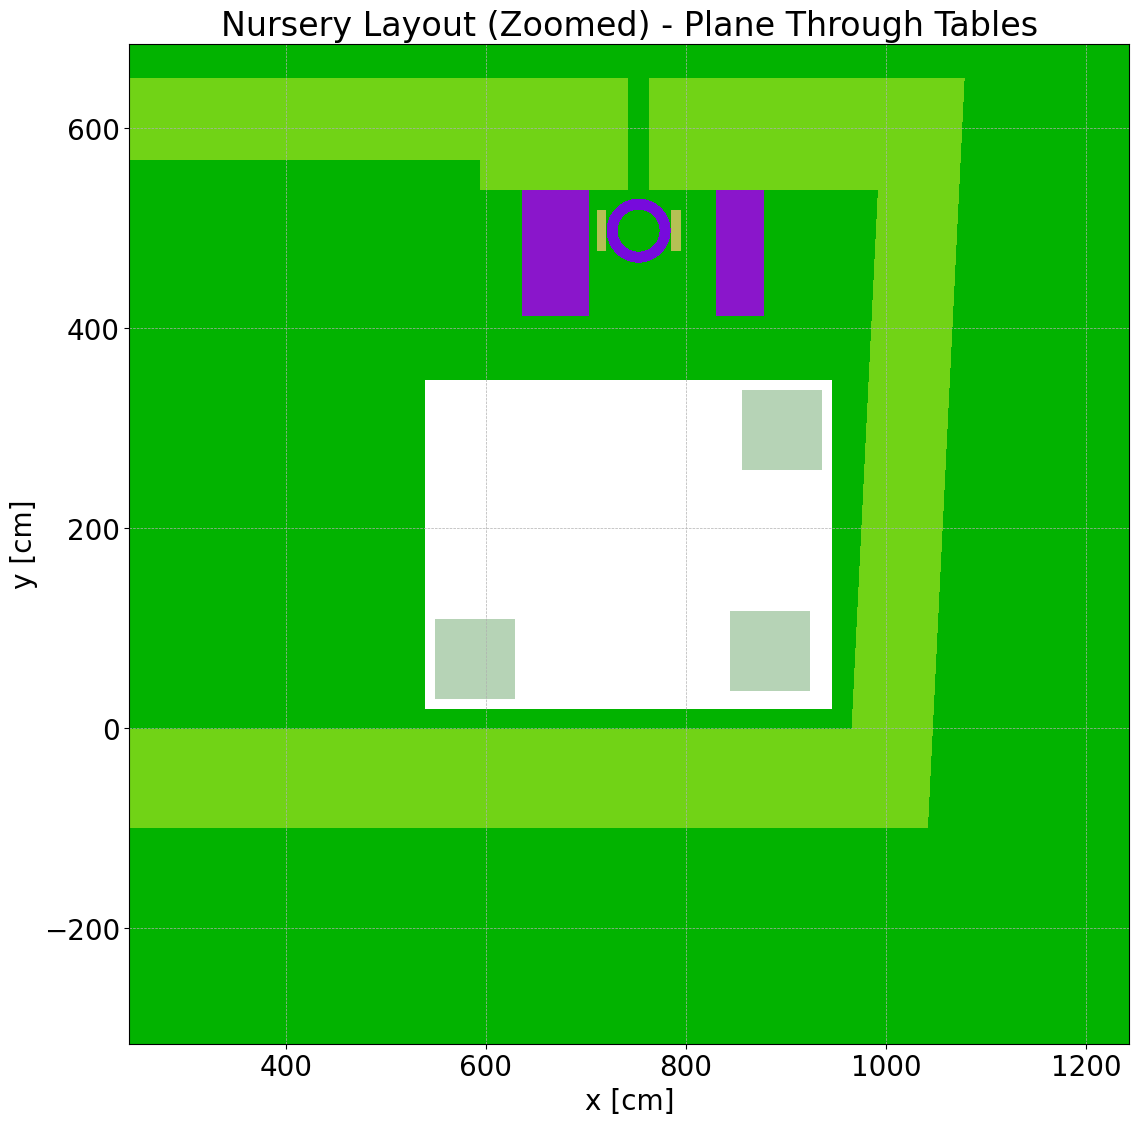

In [49]:
ax = geometry.plot(
    width=(1000, 1000),
    origin=(x_c, y_c, baby_heights[0] + 1), # z_c + 1 to cut through the table plane
    pixels=(1000, 1000),
    basis="xy",
    color_by="material",
    colors={Air: "white", air: "white"},
)
ax.tick_params(axis="both", labelsize=20)
ax.set_xlabel(ax.get_xlabel(), fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
ax.set_title("Nursery Layout (Zoomed) - Plane Through Tables", fontsize=24)
plt.grid(visible=True, which='both', linestyle='--', linewidth=0.5)  # Add gridlines
plt.show()

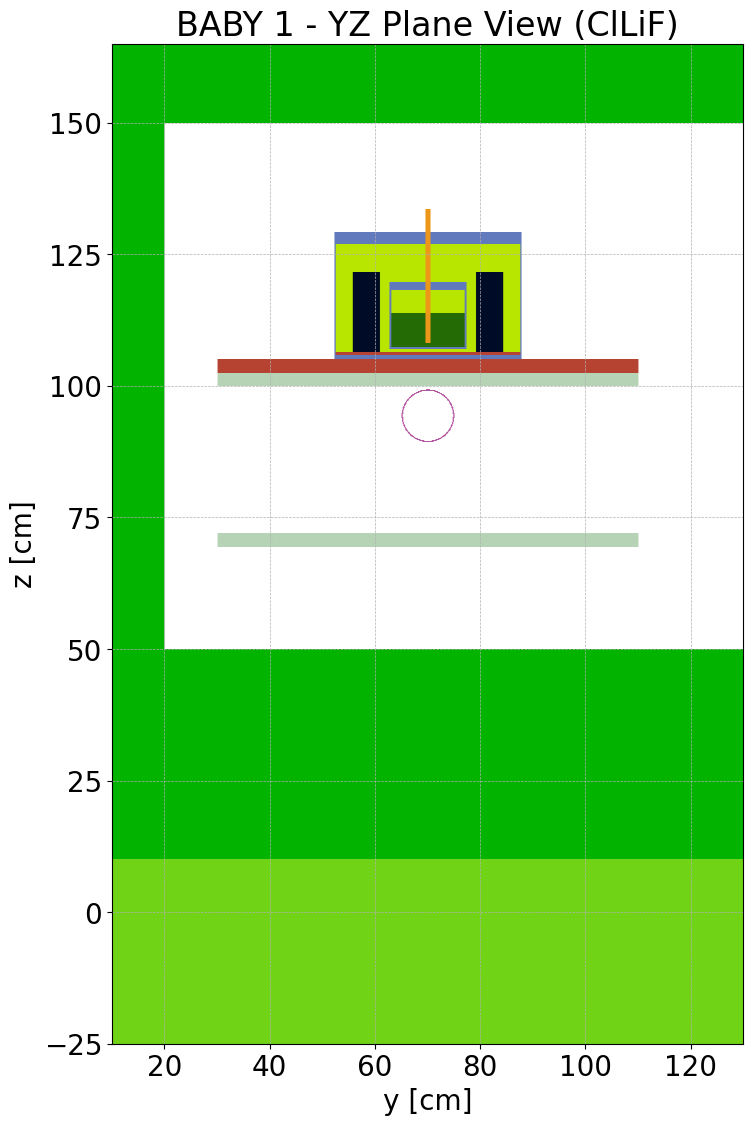

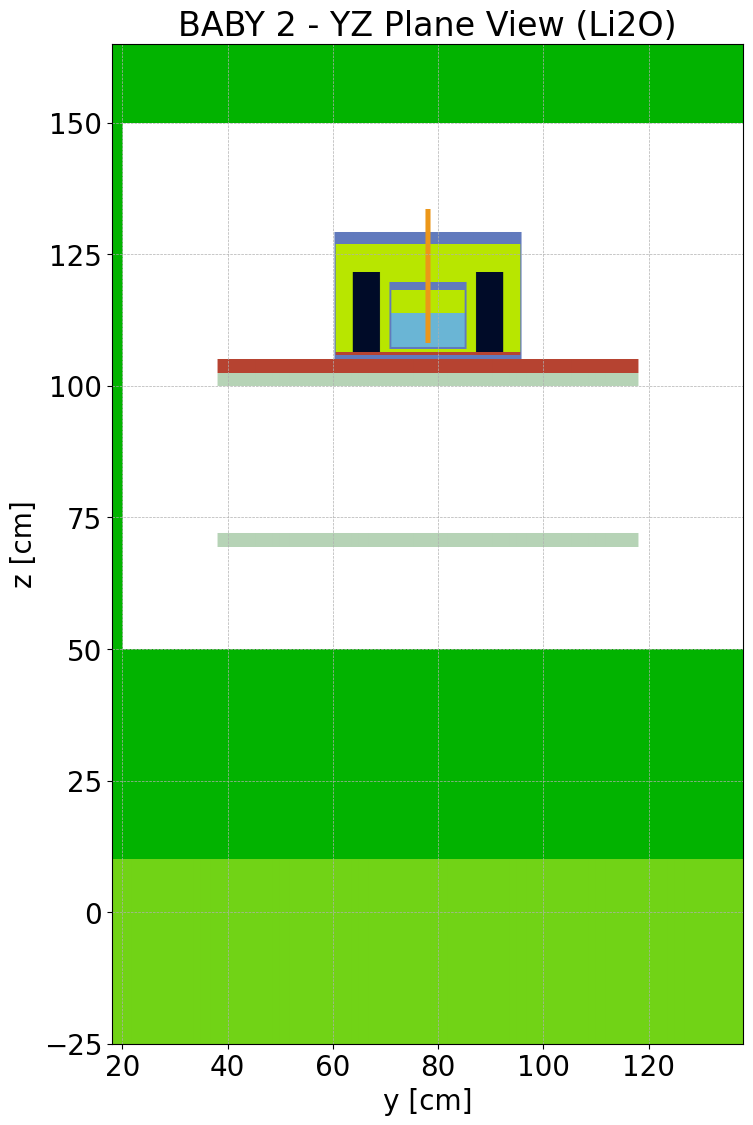

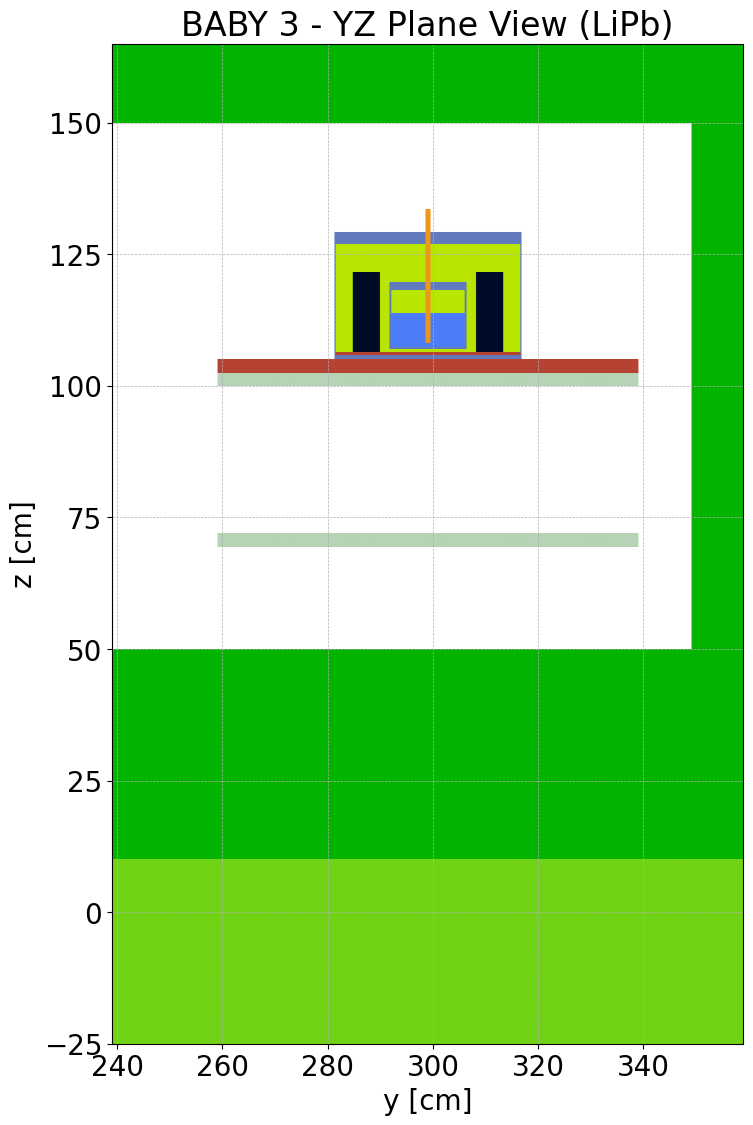

In [50]:
for i, (x_c, y_c) in enumerate(baby_positions):
    ax = geometry.plot(
        width=(120, (z_c + 40)),
        origin=(x_c, y_c, (baby_heights[0] + 40)/2),
        pixels=(1000, 1000),
        basis="yz",
        color_by="material",
        colors={Air: "white", air: "white"},
    )
    ax.tick_params(axis="both", labelsize=20)
    ax.set_xlabel(ax.get_xlabel(), fontsize=20)
    ax.set_ylabel(ax.get_ylabel(), fontsize=20)
    ax.set_title(f"BABY {i+1} - YZ Plane View ({breeders[i]})", fontsize=24)

    plt.grid(visible=True, which='both', linestyle='--', linewidth=0.5)  # Add gridlines
    plt.show()

### Display TBR results

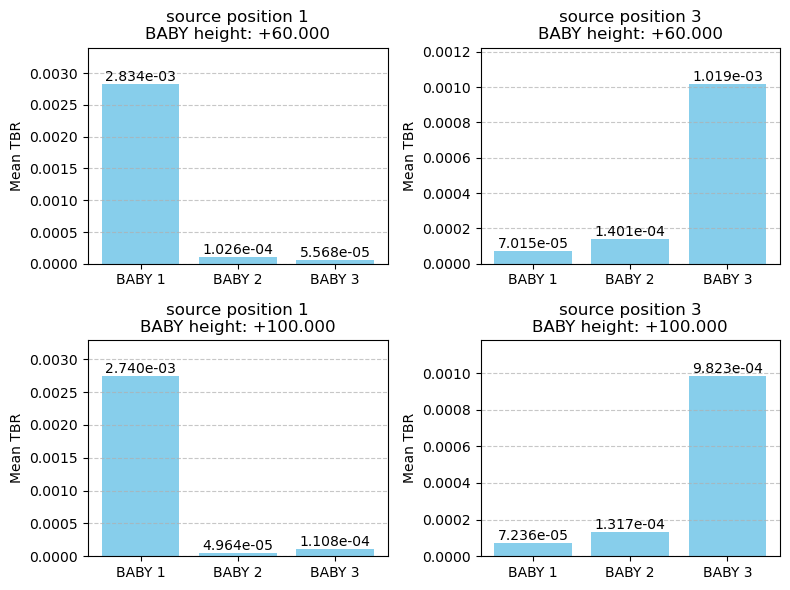

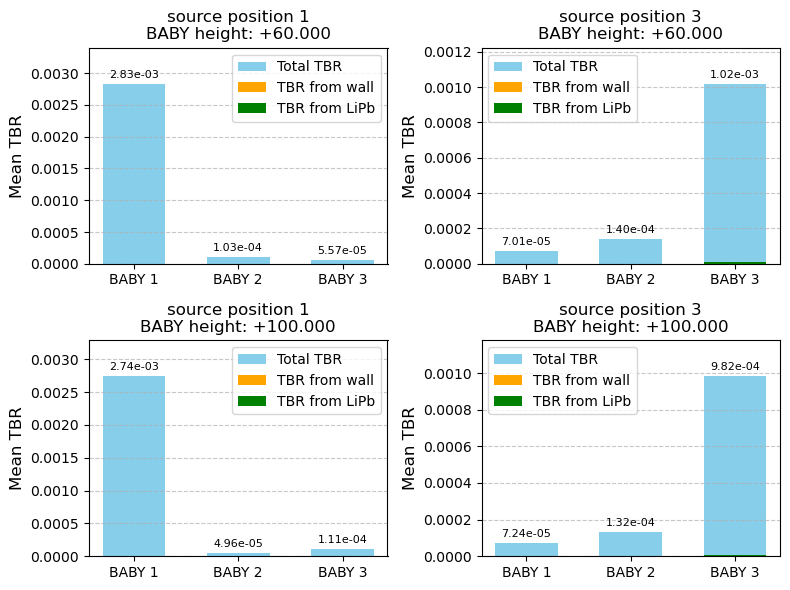

In [57]:
# Load the processed data
processed_data_file = "../../data/processed_data.json"
with open(processed_data_file, "r") as f:
    results = json.load(f)

# Get sorted source positions
def get_sp_val(key):
    try:
        return float(key.split()[-1])
    except Exception:
        return 0

source_positions = sorted(results.keys(), key=get_sp_val)

# Collect all unique heights from all source positions
heights_set = set()
for sp_key in results:
    for z_key in results[sp_key].keys():
        heights_set.add(z_key)
        
def get_z_val(zkey):
    try:
        return float(zkey.split()[1])
    except Exception:
        return 0

heights_sorted = sorted(list(heights_set), key=get_z_val)

# Create subplots grid: rows for z_offsets and columns for source positions
nrows = len(heights_sorted)
ncols = len(source_positions)
fig, axs = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), squeeze=False)

# Loop over the grid and plot the bar charts
for col, sp_key in enumerate(source_positions):
    for row, height_key in enumerate(heights_sorted):
        ax = axs[row, col]
        run_data = results[sp_key].get(height_key, {})  # results for this source pos & height
        if not run_data:
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            ax.set_title(f"{sp_key}, {height_key}")
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        # Filter for only "modelled_TBR_i" entries (ignore ones with 'from')
        baby_keys = sorted(
            [bk for bk in run_data.keys() if bk.startswith("modelled_TBR_") and "from" not in bk],
            key=lambda x: int(x.split('_')[-1])
        )
        tbr_means = [run_data[bk]["mean"] for bk in baby_keys]
        labels = [f"BABY {i+1}" for i in range(len(tbr_means))]

        bars = ax.bar(labels, tbr_means, color='skyblue')
        ax.set_ylim(0, max(tbr_means)*1.2)
        ax.set_title(f"{sp_key}\n{height_key}")
        ax.set_ylabel("Mean TBR")
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        # Add annotations: print the TBR mean above each bar
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height,
                f"{height:.3e}",
                ha='center',
                va='bottom'
            )

plt.tight_layout()
plt.show()


# --- Overlay plot: Overall TBR with contributions from wall and LiPb ---
fig, axs = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), squeeze=False)

# Loop over source positions and baby heights
for col, sp_key in enumerate(source_positions):
    for row, height_key in enumerate(heights_sorted):
        ax = axs[row, col]
        run_data = results[sp_key].get(height_key, {})
        if not run_data:
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            ax.set_title(f"{sp_key}\n{height_key}")
            ax.set_xticks([])
            ax.set_yticks([])

            continue

        # Filter for only "modelled_TBR_i" entries (ignore any keys with 'from')
        baby_keys_total = sorted(
            [bk for bk in run_data.keys() if bk.startswith("modelled_TBR_") and "from" not in bk],
            key=lambda x: int(x.split('_')[-1])
        )
        n_babies = len(baby_keys_total)
        labels = [f"BABY {i+1}" for i in range(n_babies)]
        
        # Extract the total TBR and the sub-component contributions
        total_TBR = [run_data.get(f"modelled_TBR_{i+1}", {"mean": 0})["mean"] for i in range(n_babies)]
        wall_TBR  = [run_data.get(f"modelled_TBR_from_wall_{i+1}", {"mean": 0})["mean"] for i in range(n_babies)]
        lipb_TBR  = [run_data.get(f"modelled_TBR_from_LiPb_{i+1}", {"mean": 0})["mean"] for i in range(n_babies)]
        
        x = np.arange(n_babies)
        width = 0.6
        
        # Plot the total as base bars
        bars_total = ax.bar(x, total_TBR, width, label="Total TBR", color="skyblue")
        # Overlay the wall contribution
        bars_wall = ax.bar(x, wall_TBR, width, label="TBR from wall", color="orange")
        # Overlay the LiPb contribution (stacked on top of wall contribution)
        bars_lipb = ax.bar(x, lipb_TBR, width, label="TBR from LiPb", color="green", bottom=wall_TBR)
        
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_ylim(0, (max(total_TBR) if total_TBR else 1)*1.2)
        ax.set_ylabel("Mean TBR", fontsize=12)
        ax.set_title(f"{sp_key}\n{height_key}", fontsize=12)
        ax.legend(fontsize=10, loc='best')
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Annotate total TBR values above the bars
        for bar in bars_total:
            height_bar = bar.get_height()
            ax.annotate(f"{height_bar:.2e}",
                        xy=(bar.get_x() + bar.get_width()/2, height_bar),
                        xytext=(0,3), textcoords="offset points",
                        ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

### Results print out

In [52]:
# --- Print out TBR results after the plot ---
print("\nTBR Results Summary:")
for sp_key in source_positions:
    print(f"\nSource Position: {sp_key}")
    for z_key in sorted(results[sp_key].keys(), key=get_z_val):
        print(f"  {z_key}:")
        run_data = results[sp_key][z_key]
        # Filter to include only keys starting with "modelled_TBR_" (and ignore keys containing 'from')
        baby_keys = sorted(
            [bk for bk in run_data.keys() if bk.startswith("modelled_TBR_") and "from" not in bk],
            key=lambda x: int(x.split('_')[-1])
        )
        for bk in baby_keys:
            mean = run_data[bk]["mean"]
            std_dev = run_data[bk]["std_dev"]
            rel_std_dev = run_data[bk].get("relative_std_dev", std_dev/mean if mean != 0 else 0)
            print(f"    {bk}: Mean = {mean:.6e}, Std Dev = {std_dev:.6e}, Relative Std Dev = {rel_std_dev:.6e}")

print("end")


TBR Results Summary:

Source Position: source position 1
  BABY height: +100.000:
    modelled_TBR_1: Mean = 2.740137e-03, Std Dev = 1.133013e-04, Relative Std Dev = 4.134879e-02
    modelled_TBR_2: Mean = 4.964372e-05, Std Dev = 1.433374e-05, Relative Std Dev = 2.887322e-01
    modelled_TBR_3: Mean = 1.108075e-04, Std Dev = 4.715439e-05, Relative Std Dev = 4.255523e-01
  BABY height: +60.000:
    modelled_TBR_1: Mean = 2.833532e-03, Std Dev = 1.101889e-04, Relative Std Dev = 3.888747e-02
    modelled_TBR_2: Mean = 1.026448e-04, Std Dev = 3.199316e-05, Relative Std Dev = 3.116880e-01
    modelled_TBR_3: Mean = 5.568476e-05, Std Dev = 3.225655e-05, Relative Std Dev = 5.792707e-01

Source Position: source position 3
  BABY height: +100.000:
    modelled_TBR_1: Mean = 7.236478e-05, Std Dev = 3.131312e-05, Relative Std Dev = 4.327122e-01
    modelled_TBR_2: Mean = 1.317209e-04, Std Dev = 3.132120e-05, Relative Std Dev = 2.377845e-01
    modelled_TBR_3: Mean = 9.823412e-04, Std Dev = 1.194